# Домашнее задание №1: Online Shoppers Purchasing Intention

В этом проекте по данным пользовательских сессий нужно предсказать, была ли покупка (`Revenue`). Сначала посмотрим на данные и их ограничения, затем по результатам EDA сформулируем гипотезы и проверим их моделями.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = Path("data") / "online_shoppers_intention.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Не найден файл {data_path}. "
        "Проверьте, что датасет лежит в папке data рядом с ноутбуком."
    )

df = pd.read_csv(data_path)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.shape

(12330, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 1. Знакомство с данными

В датасете есть признаки поведения на сайте, категориальные признаки сессии и бинарная целевая переменная `Revenue`.

- `Administrative`, `Informational`, `ProductRelated` и соответствующие `_Duration` - просмотры и время;
- `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay` - поведенческие и календарные признаки;
- `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `Month`, `VisitorType`, `Weekend` - категориальные признаки;
- `Revenue` - факт покупки во время сессии.

In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
print("Дубликатов:", df.duplicated().sum())
df[df.duplicated()].head()

Дубликатов: 125


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False


In [8]:
df[df.duplicated()].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,125.0,125.0,125.0,125.0,125.000000,125.0,1.250000e+02,1.250000e+02,125.0,125.000000,125.000000,125.000000,125.000000,125.000000
mean,0.0,0.0,0.0,0.0,1.056000,0.0,2.000000e-01,2.000000e-01,0.0,0.011200,2.104000,2.288000,2.568000,3.648000
std,0.0,0.0,0.0,0.0,0.230847,0.0,4.737436e-16,4.737436e-16,0.0,0.089096,1.281531,2.320373,2.262371,4.784478
min,0.0,0.0,0.0,0.0,1.000000,0.0,2.000000e-01,2.000000e-01,0.0,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.0,0.0,0.0,0.0,1.000000,0.0,2.000000e-01,2.000000e-01,0.0,0.000000,1.000000,1.000000,1.000000,1.000000
50%,0.0,0.0,0.0,0.0,1.000000,0.0,2.000000e-01,2.000000e-01,0.0,0.000000,2.000000,2.000000,1.000000,1.000000
75%,0.0,0.0,0.0,0.0,1.000000,0.0,2.000000e-01,2.000000e-01,0.0,0.000000,2.000000,2.000000,3.000000,3.000000
max,0.0,0.0,0.0,0.0,2.000000,0.0,2.000000e-01,2.000000e-01,0.0,0.800000,8.000000,13.000000,9.000000,20.000000


Пропусков нет. Точные дубликаты есть: по самим признакам нельзя определить, являются ли это повторно записанные строки или реальные одинаковые короткие сессии.

Для моделирования точные копии всё же удаляем. Иначе одинаковая строка может случайно попасть и в train, и в test, из-за чего оценка качества будет немного завышена. Удаляем только полные совпадения всех столбцов; выбросы и просто похожие сессии не трогаем.

In [9]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f"Строк до удаления дубликатов: {rows_before}")
print(f"Строк после удаления дубликатов: {len(df)}")
print(f"Удалено точных дубликатов: {rows_before - len(df)}")

Строк до удаления дубликатов: 12330
Строк после удаления дубликатов: 12205
Удалено точных дубликатов: 125


Перед EDA, в котором используется целевая переменная, отделяем test. Базовую проверку структуры, пропусков и дубликатов мы уже сделали на всём файле, а распределения по `Revenue`, корреляции с целью и формулирование гипотез выполняем только на train.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Revenue")
y = df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

eda_df = X_train.copy()
eda_df["Revenue"] = y_train

print("Train:", X_train.shape, "доля покупок:", y_train.mean().round(4))
print("Test: ", X_test.shape, "доля покупок:", y_test.mean().round(4))

Train: (9764, 17) доля покупок: 0.1563
Test:  (2441, 17) доля покупок: 0.1565


## 2. Целевая переменная

Сначала посмотрим, насколько часто пользователь совершает покупку. Если положительный класс редкий, accuracy будет слишком оптимистичной метрикой: можно получать высокую accuracy, почти всегда предсказывая отсутствие покупки.

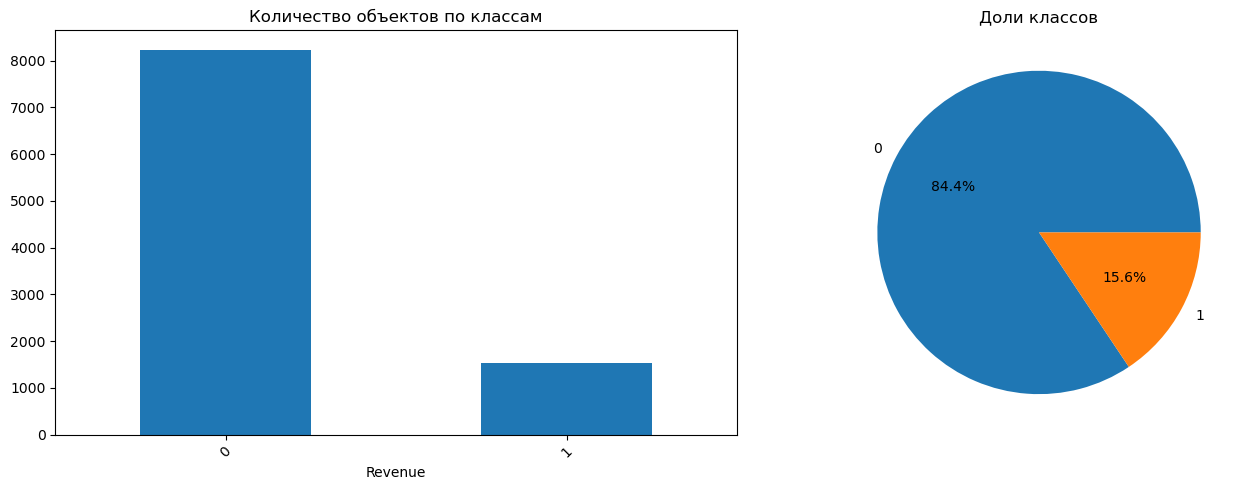

In [11]:
target_col = 'Revenue'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eda_df[target_col].value_counts().plot.bar(ax=axes[0])
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

eda_df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%')
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

### Гипотеза H1: балансировка классов

В `Revenue` положительный класс заметно реже отрицательного. Проверим, повысит ли `class_weight="balanced"` recall покупок и одновременно снизит precision.

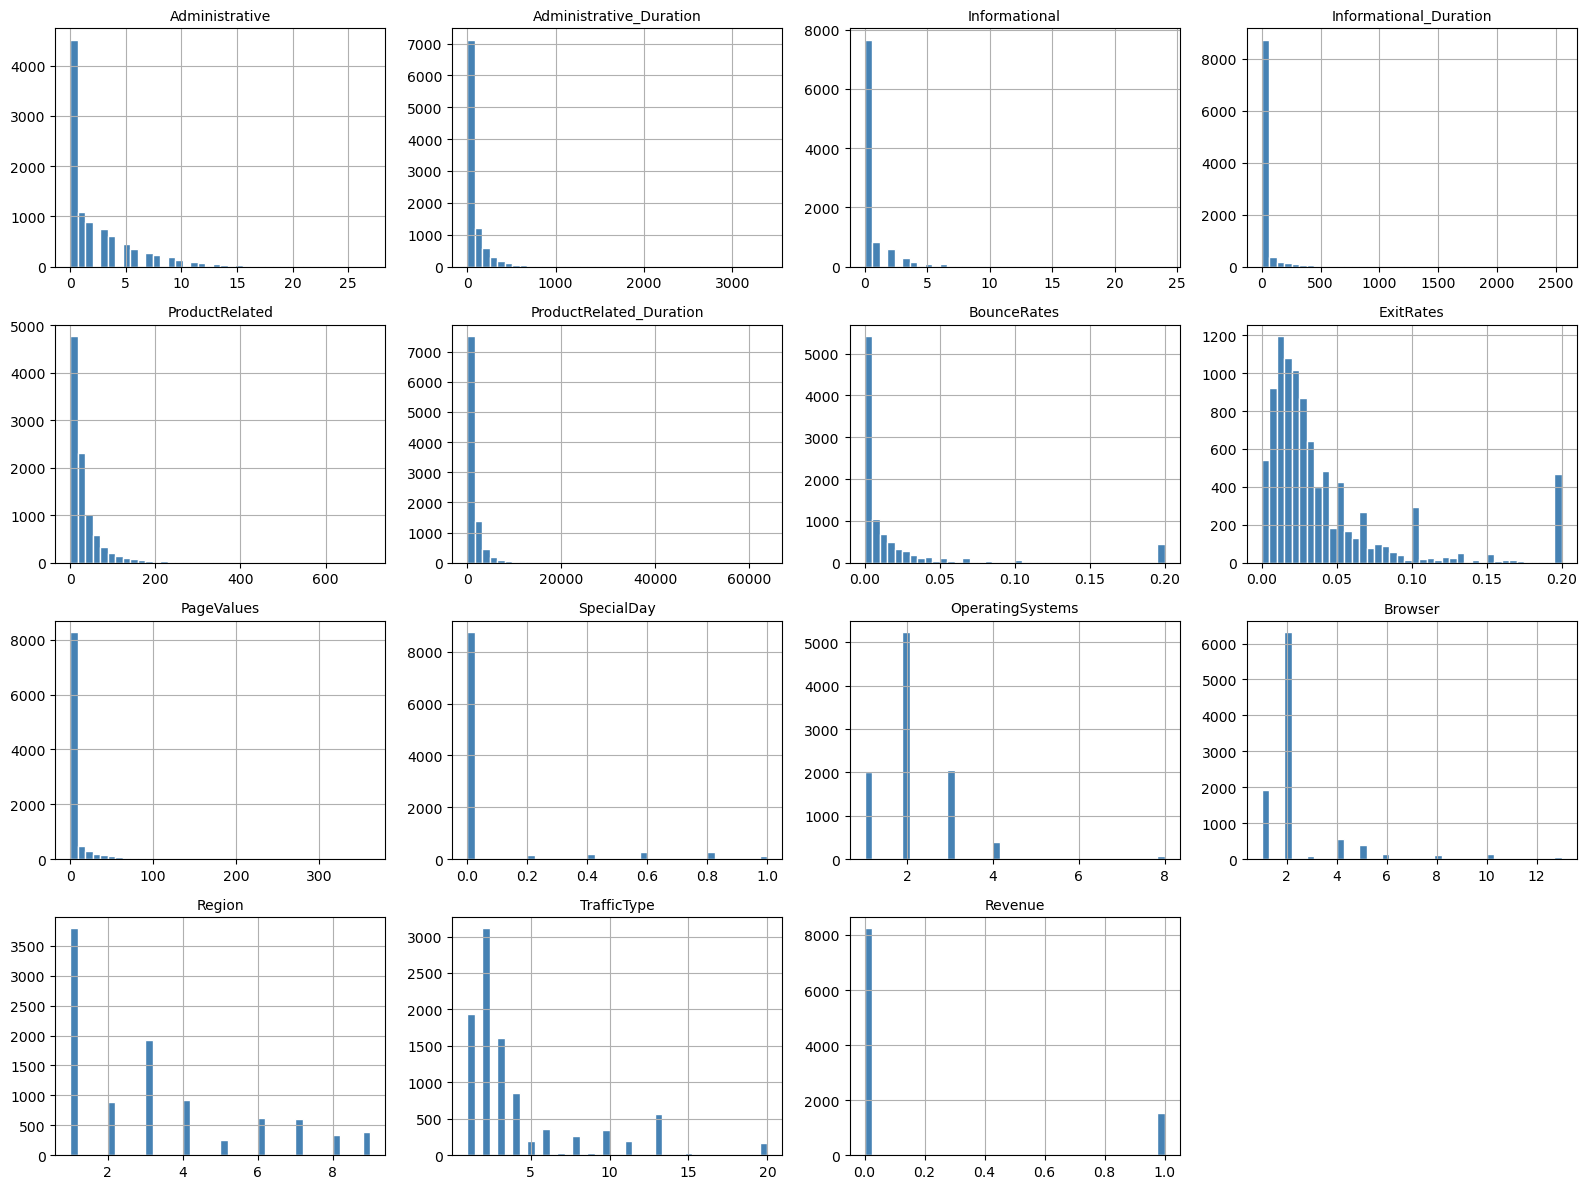

In [12]:
numeric_cols_for_hist = eda_df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols_for_hist)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_for_hist):
    eda_df[col].hist(bins=40, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=10)

for ax in axes[len(numeric_cols_for_hist):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

На гистограммах видно, что числовые признаки имеют разные масштабы и длинные хвосты: у большинства сессий значения близки к нулю, но встречаются очень большие значения времени и количества просмотров.

### Гипотеза H2: масштабирование

Масштабирование сильнее повлияет на качество Logistic Regression, чем на качество Random Forest. Для линейной модели масштаб признаков важен, а деревья сравнивают значения внутри отдельных признаков.

Сессий с Administrative_Duration > 1500: 25 (0.26% от датасета)


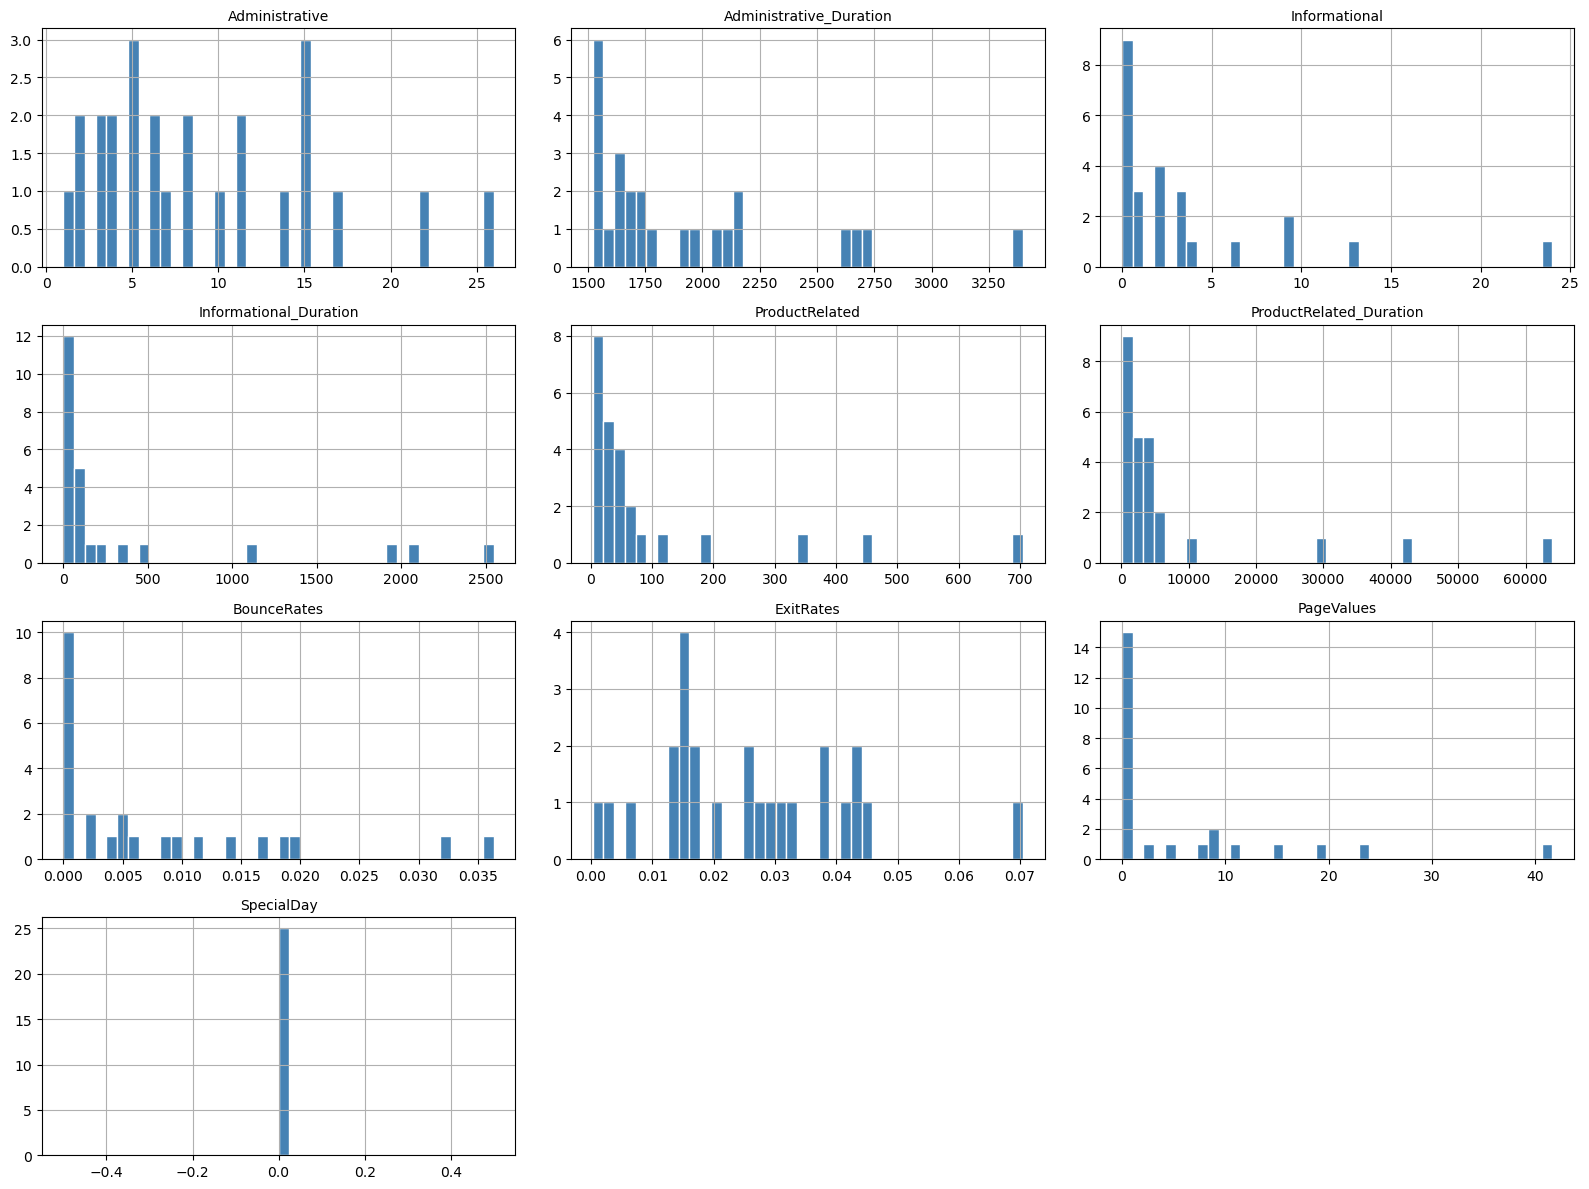

In [13]:
cat_cols = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Month",
    "VisitorType",
    "Weekend",
]

numeric_cols = [
    col
    for col in eda_df.select_dtypes(include=np.number).columns.tolist()
    if col not in cat_cols and col != "Revenue"
]

df_tail = eda_df[eda_df["Administrative_Duration"] > 1500]

print(
    "Сессий с Administrative_Duration > 1500:",
    len(df_tail),
    f"({len(df_tail) / len(eda_df):.2%} от датасета)",
)

n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_tail[col].hist(bins=40, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=10)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Отдельный график по большим значениям `Administrative_Duration` нужен только для понимания хвоста распределения. Мы не удаляем эти строки: большое время на сайте может быть реальным поведением пользователя, а не ошибкой измерения. Позже сравним линейную модель с деревьями, которые по-разному реагируют на масштаб и длинные хвосты.

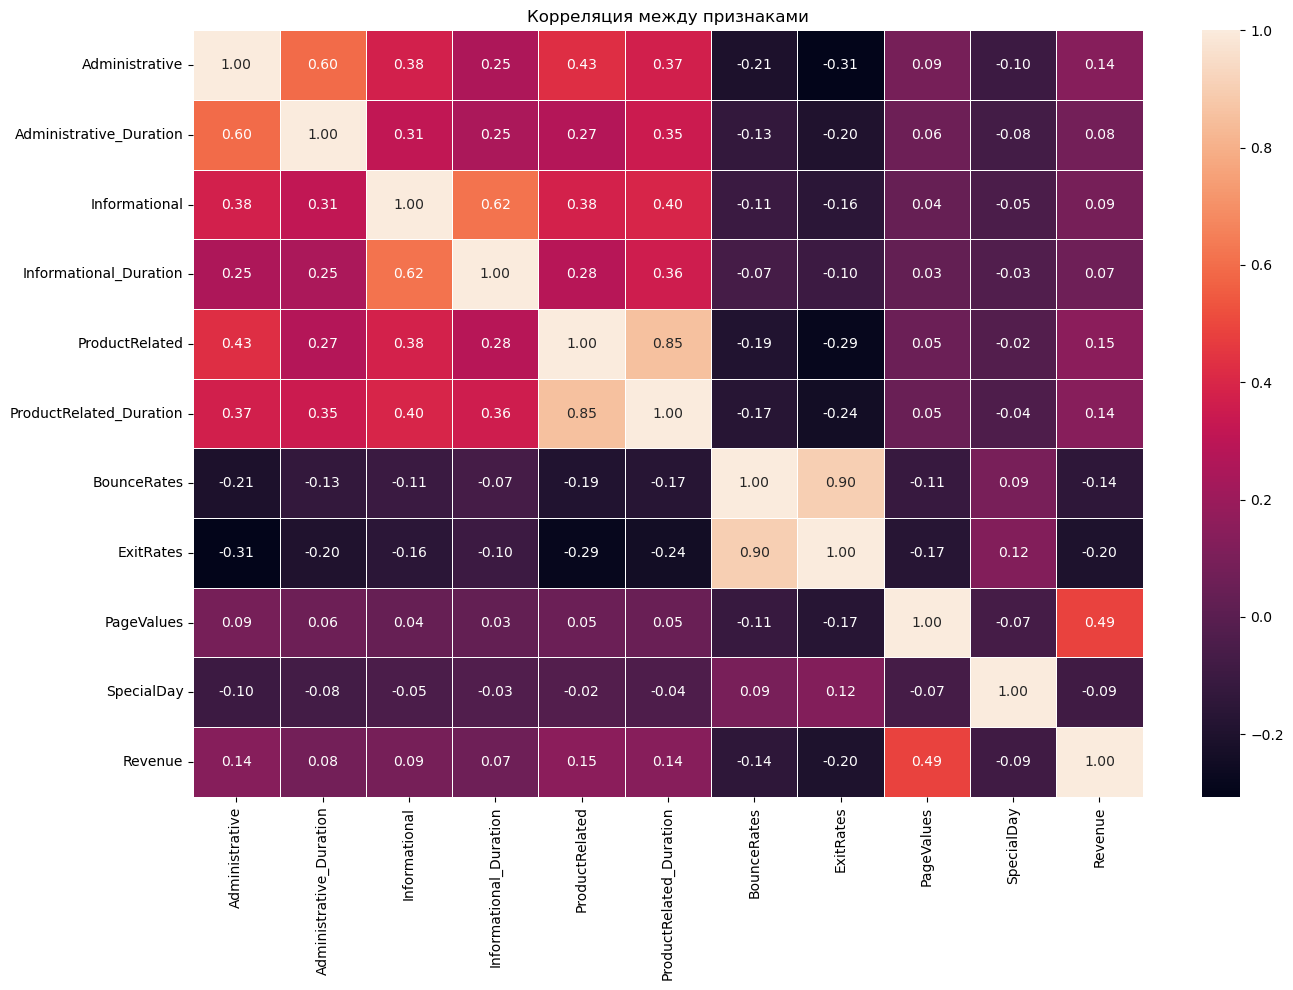

In [14]:
plt.figure(figsize=(14, 10))
corr = eda_df[numeric_cols + ["Revenue"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", linewidth=0.5)
plt.title("Корреляция между признаками")
plt.tight_layout()
plt.show()

Корреляции с целевой переменной умеренные: заметнее всего `PageValues`. Между самими признаками есть сильные связи, в частности между `BounceRates` и `ExitRates`, а также между количеством просмотров товарных страниц и временем на них.

`PageValues` оставляем в работе, потому что он входит в исходный датасет. Для реального внедрения отдельно пришлось бы проверить, доступен ли этот показатель в тот момент, когда модель должна сделать прогноз. Если он рассчитывается только после завершения сессии, это ограничит практическое применение модели.

### Гипотезы H3 и H4: коррелированные признаки

- H3: top-5 признаков по impurity importance и permutation importance будут отличаться.
- H4: удаление `ExitRates` сильнее изменит качество Logistic Regression, чем качество Random Forest.

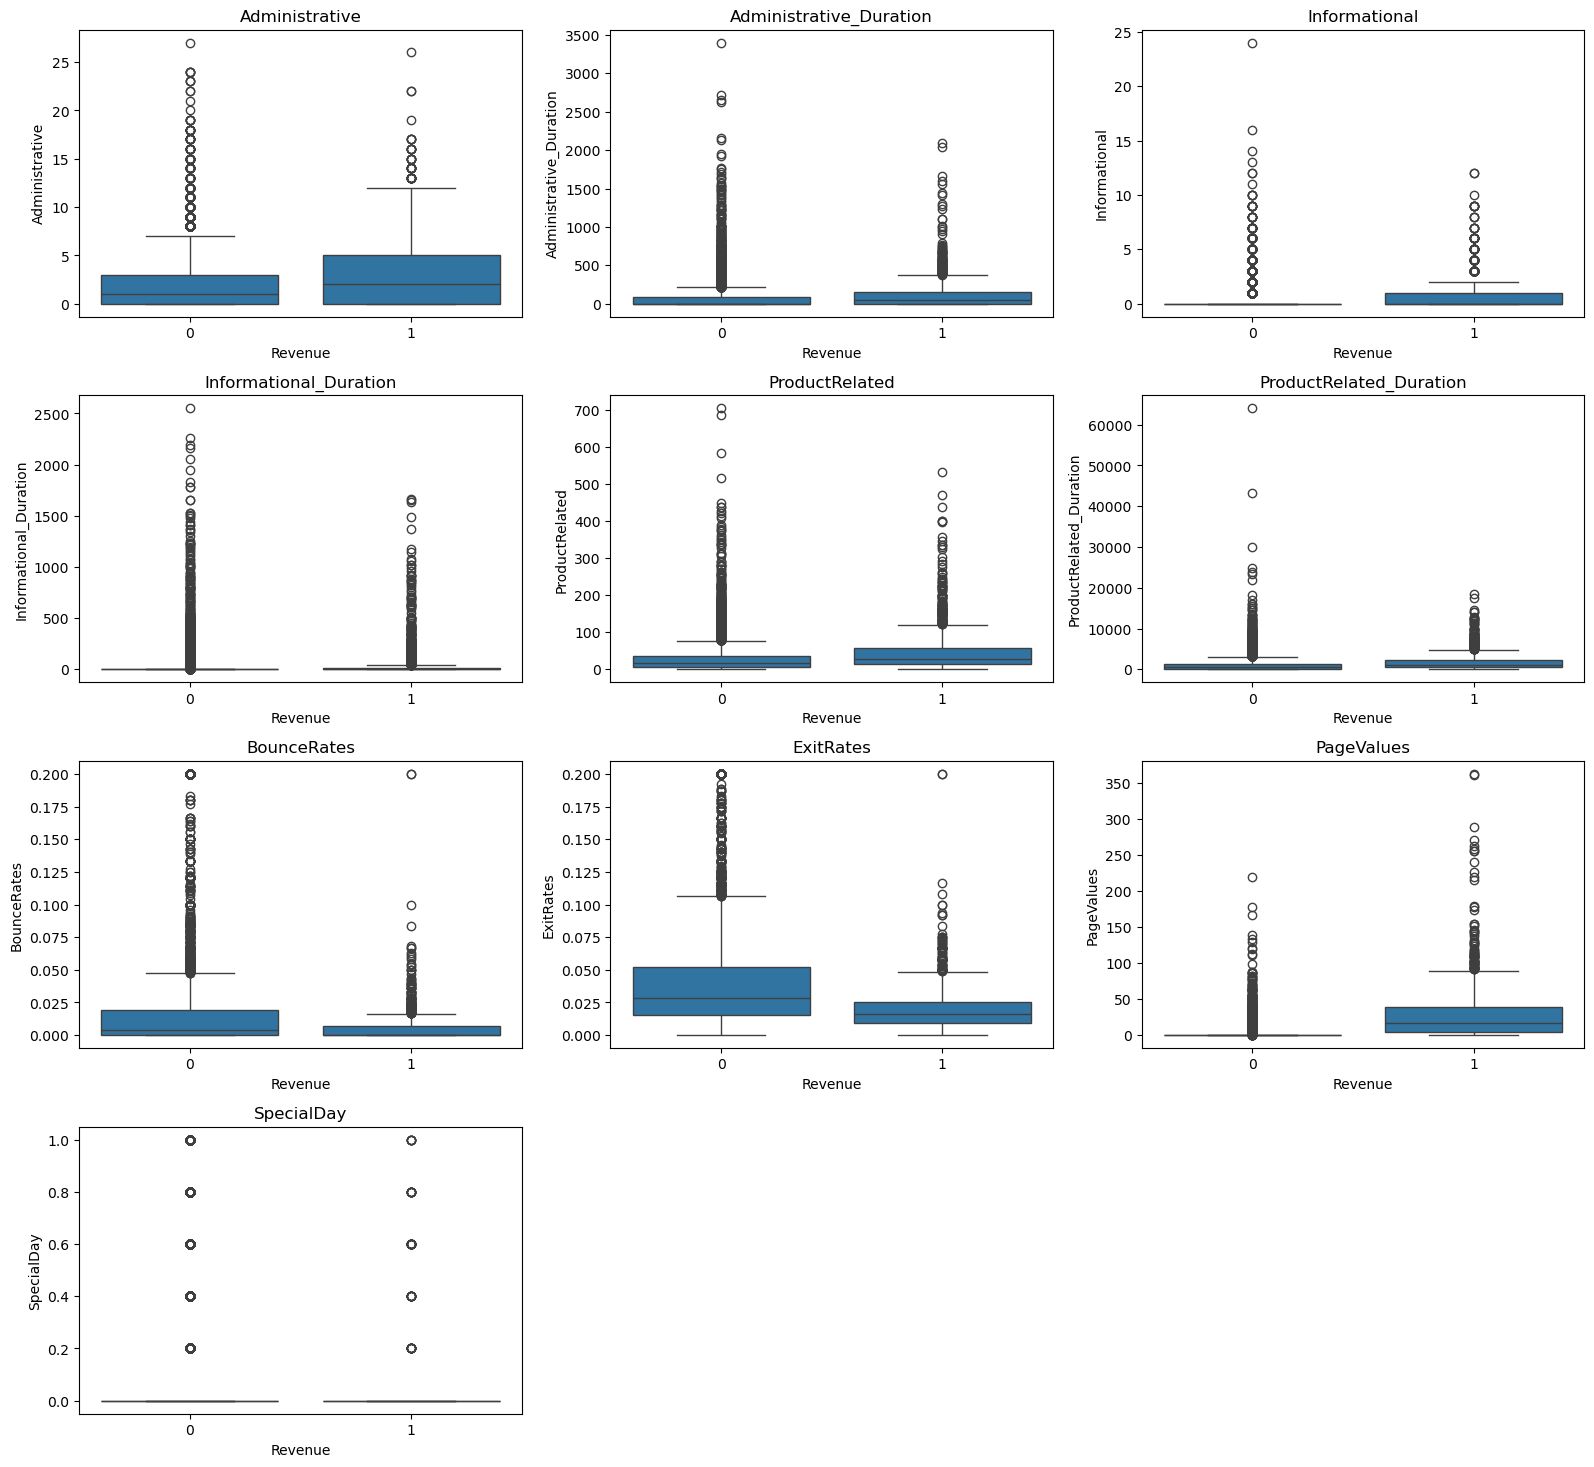

In [15]:
fig, axes = plt.subplots(5, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(
        data=eda_df,
        x="Revenue",
        y=col,
        ax=ax,
    )
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Boxplot показывает ту же картину в разрезе `Revenue`: у покупательских сессий чаще выше активность на товарных страницах, а `BounceRates` и `ExitRates` ниже. Выбросов много, но пока не удаляем их автоматически: сначала сравним модели, которые по-разному работают с нелинейностями и хвостами.

## 3. Категориальные признаки

Для каждой категории считаем число сессий, число покупок и долю покупок. Сравнивать только количество покупок было бы неправильно: частые категории почти всегда будут лидировать просто из-за большего числа наблюдений.

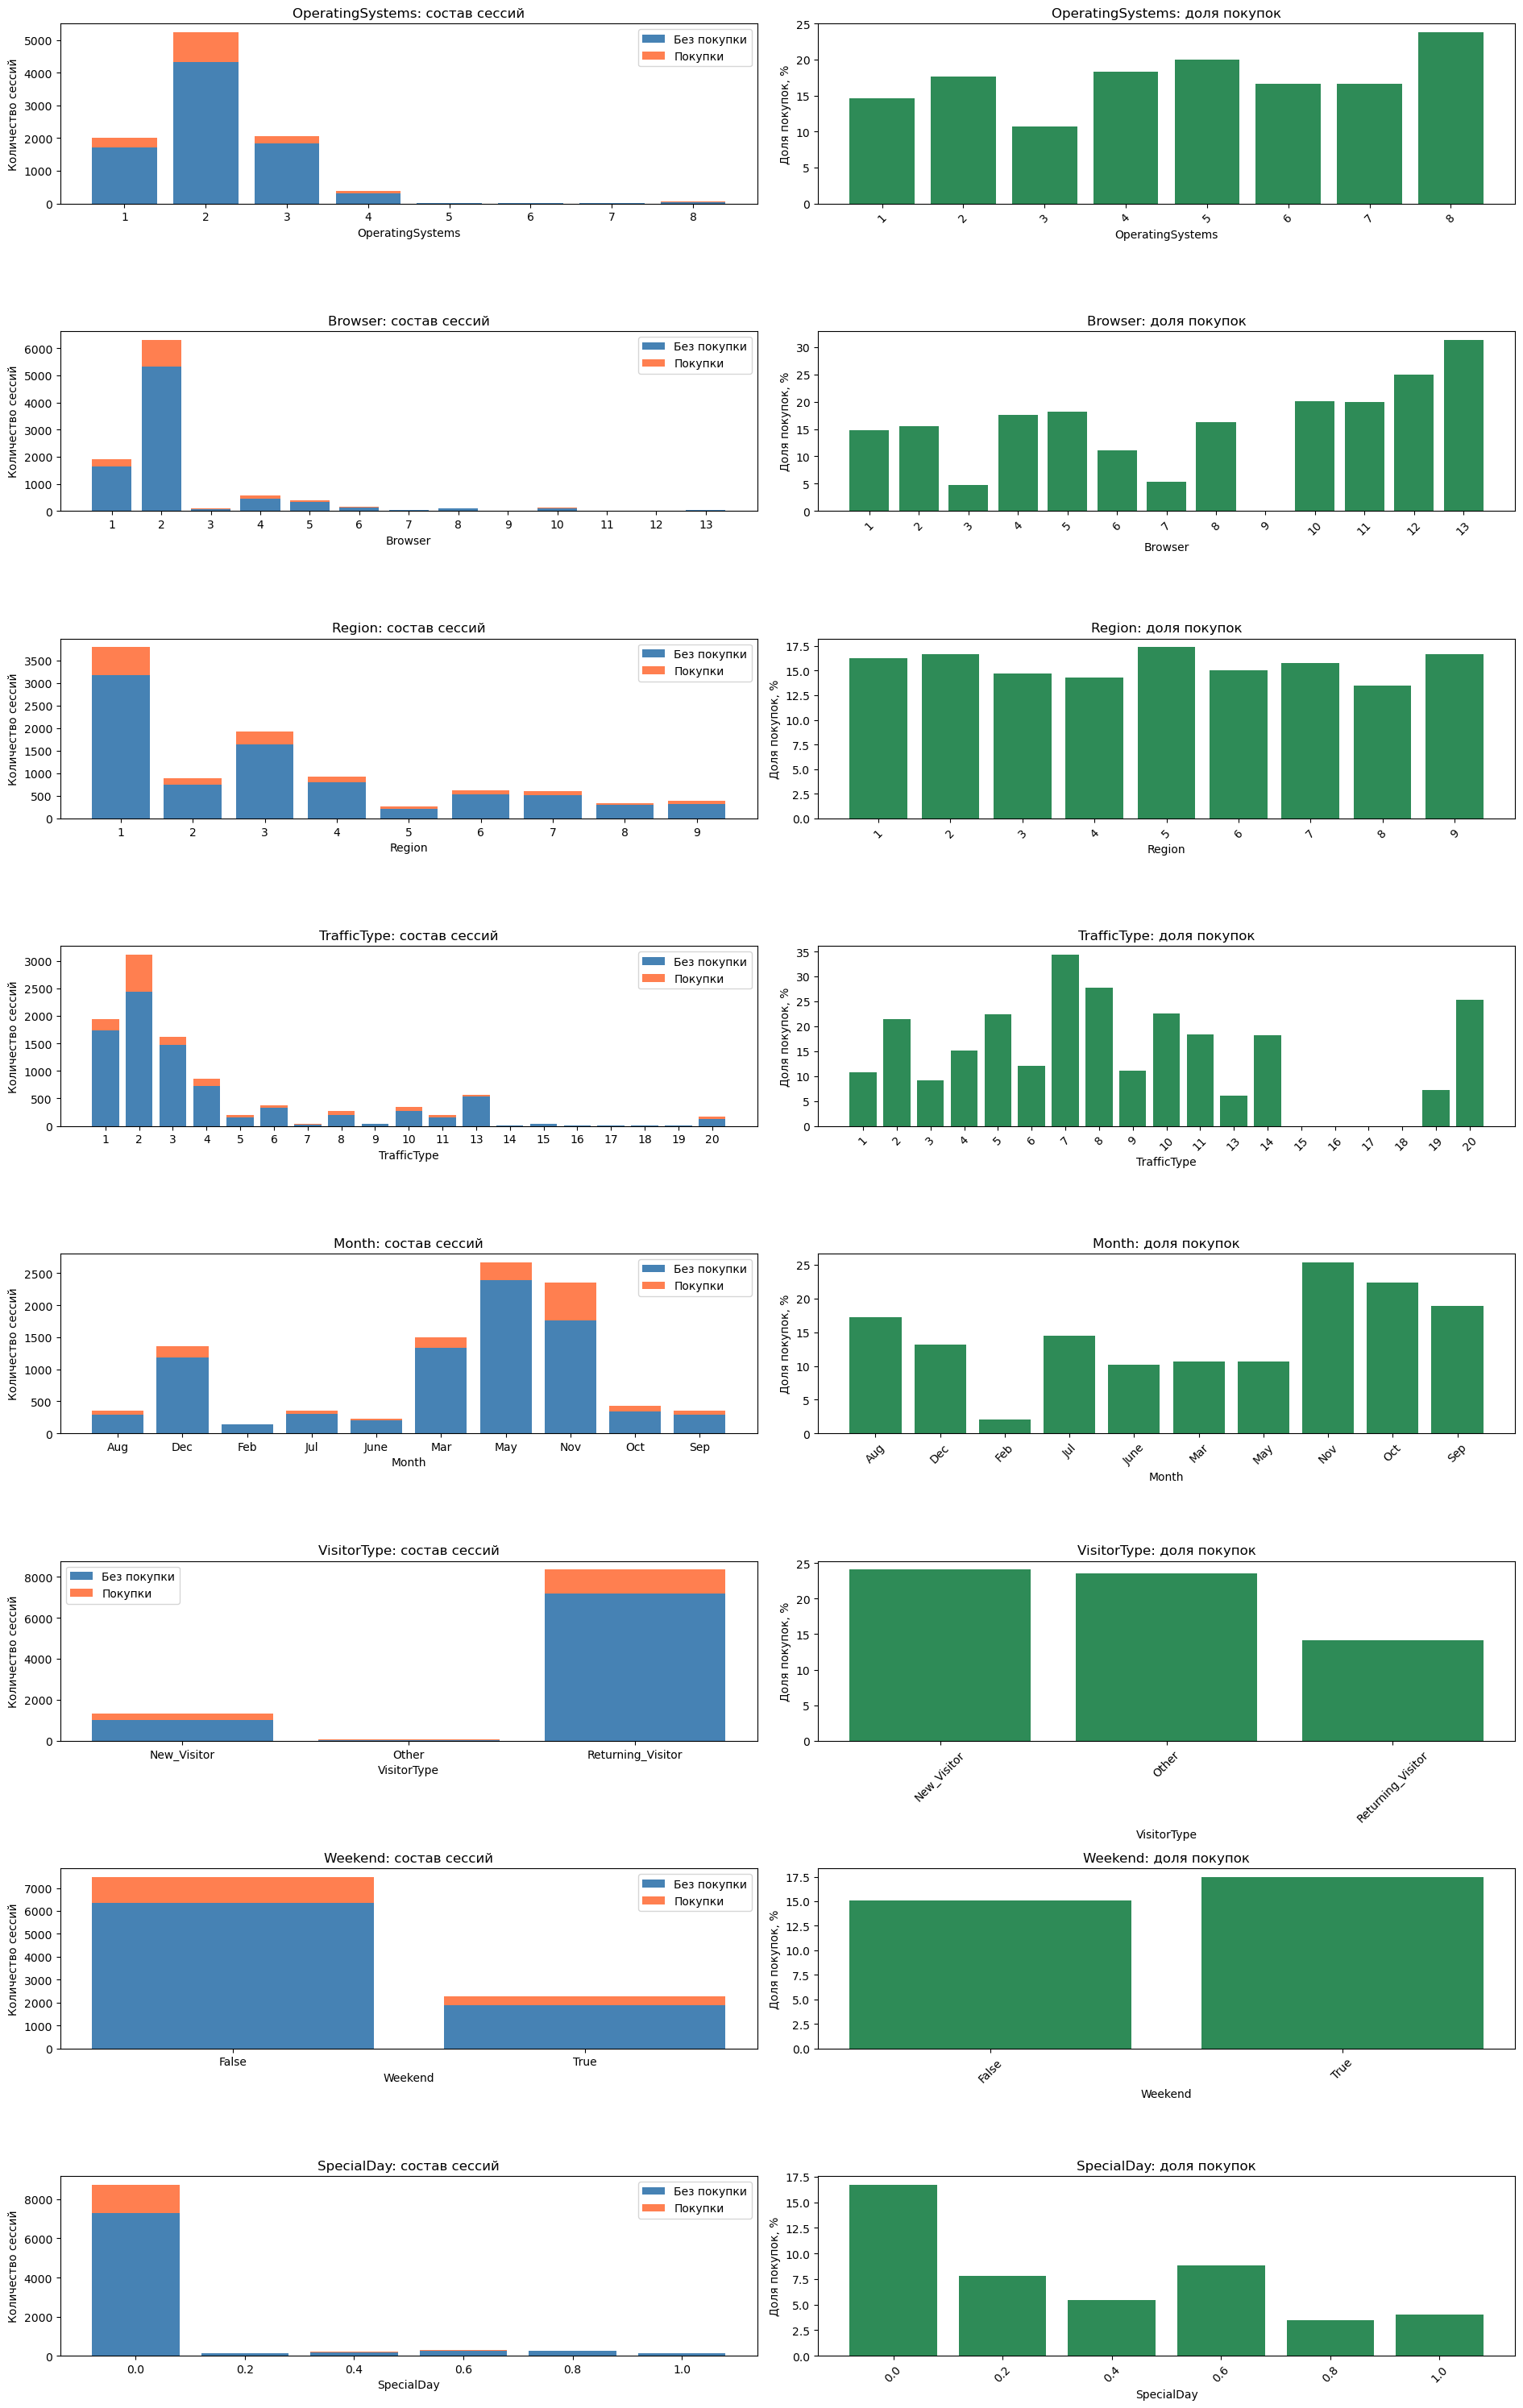

In [16]:
fig, axes = plt.subplots(len(cat_cols + ['SpecialDay']), 2, figsize=(19, 30))

for i, col in enumerate(cat_cols + ['SpecialDay']):
    info = (
        eda_df.groupby(col)
          .agg(
              sessions=("Revenue", "size"),
              purchases=("Revenue", "sum"),
              purchase_share=("Revenue", "mean")
          )
    )

    labels = info.index.astype(str)
    non_purchases = info["sessions"] - info["purchases"]

    ax = axes[i, 0]

    ax.bar(labels, non_purchases, label="Без покупки", color="steelblue")

    ax.bar(labels, info["purchases"], bottom=non_purchases, label="Покупки", color="coral")

    ax.set_title(f"{col}: состав сессий")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество сессий")
    ax.legend()

    # Доля покупок
    ax = axes[i, 1]

    ax.bar(labels, info["purchase_share"] * 100, color="seagreen")

    ax.set_title(f"{col}: доля покупок")
    ax.set_xlabel(col)
    ax.set_ylabel("Доля покупок, %")

    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Гипотеза H5: категориальные признаки

Категории сессии могут содержать информацию о поведении пользователей, которой нет в числовых признаках. Проверим, повысит ли One-Hot Encoding ROC-AUC Logistic Regression.

## 4. Подготовка данных

Категориальные признаки закодируем через `OneHotEncoder(handle_unknown="ignore")`. Для Logistic Regression числовые признаки масштабируем, потому что её коэффициенты и регуляризация зависят от масштаба признаков. Для деревьев масштабирование не требуется.

Все преобразования помещаем внутрь `Pipeline`. Тогда при кросс-валидации кодировщик, scaler и отбор признаков обучаются только на обучающей части каждого фолда.

In [17]:
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

После сделанного выше разбиения test больше не используем до финального раздела. Подбор параметров, сравнение вариантов и проверка гипотез проводятся только на `X_train` через одинаковые фолды кросс-валидации.

In [18]:
preprocessor_logreg = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", StandardScaler(), numeric_cols),
])

preprocessor_logreg_no_scaling = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", "passthrough", numeric_cols),
])

preprocessor_rf_gb = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", "passthrough", numeric_cols),
])

### Гипотеза H6: отбор признаков

После One-Hot Encoding признаков становится больше. Проверим, сможет ли `SelectKBest` реально сократить их число и при этом получить средний CV ROC-AUC не ниже, чем у той же Logistic Regression без отбора.

## 5. Схема оценки

Используем `StratifiedKFold` с пятью одинаковыми фолдами: в каждом сохраняется доля покупок. Основная метрика для подбора параметров - ROC-AUC. Дополнительно считаем Average Precision, precision, recall и F1, потому что положительный класс встречается заметно реже.

Ниже есть три небольшие функции:

- `tune_model` подбирает параметры только на train;
- `evaluate_cv` сравнивает уже зафиксированные модели на одинаковых фолдах;
- `evaluate_on_test` вызывается только в финальном разделе.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}


def tune_model(model, param_grid, X_train, y_train, cv, model_name, n_jobs=-1):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        return_train_score=False,
    )
    grid.fit(X_train, y_train)

    fold_scores = np.array([
        grid.cv_results_[f"split{i}_test_score"][grid.best_index_]
        for i in range(cv.get_n_splits())
    ])

    return {
        "model_name": model_name,
        "best_model": grid.best_estimator_,
        "best_params": grid.best_params_,
        "best_cv_roc_auc": grid.best_score_,
        "best_cv_roc_auc_std": fold_scores.std(ddof=1),
        "fold_roc_auc": fold_scores,
    }


def evaluate_cv(model, X, y, cv, model_name, n_jobs=-1):
    scores = cross_validate(
        clone(model),
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        error_score="raise",
    )

    result = {"model": model_name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        result[f"cv_{metric}_mean"] = values.mean()
        result[f"cv_{metric}_std"] = values.std(ddof=1)

    result["fold_roc_auc"] = scores["test_roc_auc"]
    return result


def evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name):
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred = fitted_model.predict(X_test)
    if hasattr(fitted_model, "predict_proba"):
        y_score = fitted_model.predict_proba(X_test)[:, 1]
    else:
        y_score = fitted_model.decision_function(X_test)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score),
        "fitted_model": fitted_model,
    }


def cv_table(*results):
    rows = []
    for result in results:
        rows.append({
            key: value
            for key, value in result.items()
            if key != "fold_roc_auc"
        })
    return pd.DataFrame(rows)


def paired_roc_auc_table(result_a, result_b, name_a, name_b):
    scores_a = np.asarray(result_a["fold_roc_auc"])
    scores_b = np.asarray(result_b["fold_roc_auc"])
    delta = scores_a - scores_b

    table = pd.DataFrame({
        "fold": np.arange(1, len(delta) + 1),
        name_a: scores_a,
        name_b: scores_b,
        "difference": delta,
    })

    print(f"Средняя разница {name_a} - {name_b}: {delta.mean():.6f}")
    print(f"Стандартное отклонение разницы: {delta.std(ddof=1):.6f}")
    print(f"Фолдов, где {name_a} лучше: {(delta > 0).sum()} из {len(delta)}")

    return table

## 6. Модели

Начинаем с Logistic Regression как простого линейного baseline. Затем сравниваем её с Random Forest и Gradient Boosting, которые могут находить нелинейные зависимости и взаимодействия между признаками.

Параметры подбираются только по CV ROC-AUC на train. Test здесь не используется.

In [20]:
grid_params_logreg = {
    "selector__k": [3, 5, 8, "all"],
    "classifier__solver": ["liblinear"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
}

model_logreg = Pipeline([
    ("preprocessor", preprocessor_logreg),
    ("selector", SelectKBest(score_func=f_classif)),
    ("classifier", LogisticRegression(max_iter=2000)),
])

result_logreg = tune_model(
    model=model_logreg,
    param_grid=grid_params_logreg,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    model_name="Logistic Regression",
)

print("Лучшие параметры:")
display(result_logreg["best_params"])

logreg_cv = evaluate_cv(
    result_logreg["best_model"],
    X_train,
    y_train,
    cv,
    "Logistic Regression",
)
cv_table(logreg_cv)

Лучшие параметры:


{'classifier__C': 0.1,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1',
 'classifier__solver': 'liblinear',
 'selector__k': 'all'}

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,Logistic Regression,0.903041,0.011896,0.651431,0.025234,0.530712,0.028213,0.756886,0.0276,0.623745,0.026619


### Эксперимент H5: добавление категориальных признаков

Сравним Logistic Regression на полном наборе и только на числовых признаках. Для обеих моделей используем одну и ту же сетку параметров и одинаковые CV-фолды.

Такой эксперимент отвечает на вопрос: даёт ли добавление категориальной информации прирост у лучшей настроенной Logistic Regression, а не просто у одной случайно выбранной конфигурации.

In [21]:
preprocessor_numeric_only = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_cols),
    ("categorical", "drop", cat_cols),
])

model_logreg_numeric_only = Pipeline([
    ("preprocessor", preprocessor_numeric_only),
    ("selector", SelectKBest(score_func=f_classif)),
    ("classifier", LogisticRegression(max_iter=2000)),
])

result_logreg_numeric_only = tune_model(
    model=model_logreg_numeric_only,
    param_grid=grid_params_logreg,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    model_name="Logistic Regression: только числовые признаки",
)

numeric_only_cv = evaluate_cv(
    result_logreg_numeric_only["best_model"],
    X_train,
    y_train,
    cv,
    "Logistic Regression: только числовые признаки",
)

cv_table(logreg_cv, numeric_only_cv)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,Logistic Regression,0.903041,0.011896,0.651431,0.025234,0.530712,0.028213,0.756886,0.02760,0.623745,0.026619
1,Logistic Regression: только числовые признаки,0.887312,0.008368,0.640819,0.016948,0.570199,0.010767,0.739837,0.03206,0.643847,0.016670


In [22]:
h5_folds = paired_roc_auc_table(
    logreg_cv,
    numeric_only_cv,
    "Все признаки",
    "Только числовые",
)
h5_folds

Средняя разница Все признаки - Только числовые: 0.015729
Стандартное отклонение разницы: 0.010940
Фолдов, где Все признаки лучше: 5 из 5


,fold,Все признаки,Только числовые,difference
0,1,0.905197,0.887202,0.017995
1,2,0.882170,0.879759,0.002411
2,3,0.909579,0.899166,0.010413
3,4,0.907015,0.891287,0.015728
4,5,0.911242,0.879144,0.032098


**Вывод по H5. Гипотеза подтвердилась.**

После добавления категориальных признаков средний CV ROC-AUC Logistic Regression вырос с 0.8873 до 0.9030. Полный набор признаков показал более высокий результат на всех пяти фолдах.

Значит, `Month`, `VisitorType`, `TrafficType` и другие категориальные признаки содержат дополнительную информацию о вероятности покупки, которой нет в числовых показателях сессии.

### Эксперимент H2: масштабирование

Чтобы проверить влияние масштабирования, нельзя одновременно менять `C`, регуляризацию, `class_weight` или число выбранных признаков. Поэтому берём лучшие параметры Logistic Regression из основного поиска и строим две одинаковые модели. Единственное различие между ними - `StandardScaler`.

In [23]:
best_lr_classifier_params = {
    key.replace("classifier__", ""): value
    for key, value in result_logreg["best_params"].items()
    if key.startswith("classifier__")
}
best_lr_k = result_logreg["best_params"]["selector__k"]

lr_scaled = Pipeline([
    ("preprocessor", preprocessor_logreg),
    ("selector", SelectKBest(score_func=f_classif, k=best_lr_k)),
    ("classifier", LogisticRegression(max_iter=2000, **best_lr_classifier_params)),
])

lr_unscaled = Pipeline([
    ("preprocessor", preprocessor_logreg_no_scaling),
    ("selector", SelectKBest(score_func=f_classif, k=best_lr_k)),
    ("classifier", LogisticRegression(max_iter=2000, **best_lr_classifier_params)),
])

lr_scaled_cv = evaluate_cv(
    lr_scaled, X_train, y_train, cv, "LogReg scaled"
)
lr_unscaled_cv = evaluate_cv(
    lr_unscaled, X_train, y_train, cv, "LogReg unscaled"
)

cv_table(lr_scaled_cv, lr_unscaled_cv)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,LogReg scaled,0.903039,0.011899,0.651429,0.025237,0.530712,0.028213,0.756886,0.027600,0.623745,0.026619
1,LogReg unscaled,0.905743,0.012060,0.650271,0.025873,0.553564,0.025366,0.739199,0.024219,0.632986,0.024695


In [24]:
h2_lr_folds = paired_roc_auc_table(
    lr_scaled_cv,
    lr_unscaled_cv,
    "LogReg scaled",
    "LogReg unscaled",
)
h2_lr_folds

Средняя разница LogReg scaled - LogReg unscaled: -0.002705
Стандартное отклонение разницы: 0.003565
Фолдов, где LogReg scaled лучше: 1 из 5


,fold,LogReg scaled,LogReg unscaled,difference
0,1,0.905193,0.908709,-0.003516
1,2,0.882162,0.885017,-0.002855
2,3,0.909581,0.906621,0.002960
3,4,0.907015,0.913944,-0.006929
4,5,0.911242,0.914426,-0.003183


## 7. Random Forest

Random Forest нужен как нелинейный ансамбль деревьев. В сетке меняем число деревьев, глубину, минимальный размер листа, долю признаков на разбиение и `class_weight`.

Модель подбирается только по CV на train. После этого её параметры фиксируются и используются в дополнительных экспериментах.

In [ ]:
grid_params_rf = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
    "classifier__max_features": ["sqrt", 0.5],
    "classifier__class_weight": [None, "balanced"],
}

model_rf = Pipeline([
    ("preprocessor", preprocessor_rf_gb),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=1)),
])

result_rf = tune_model(
    model=model_rf,
    param_grid=grid_params_rf,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    model_name="Random Forest",
)

print("Лучшие параметры:")
display(result_rf["best_params"])

rf_cv = evaluate_cv(
    result_rf["best_model"],
    X_train,
    y_train,
    cv,
    "Random Forest",
)
cv_table(rf_cv)

Теперь завершим H2 для Random Forest. Здесь также строим две модели с одинаковыми параметрами, меняя только масштабирование числовых признаков. Деревья работают с порогами внутри каждого признака, поэтому заметного эффекта от scaler не ожидается.

In [ ]:
best_rf_classifier_params = {
    key.replace("classifier__", ""): value
    for key, value in result_rf["best_params"].items()
}

rf_scaled = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("numeric", StandardScaler(), numeric_cols),
    ])),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        **best_rf_classifier_params,
    )),
])

rf_unscaled = Pipeline([
    ("preprocessor", preprocessor_rf_gb),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        **best_rf_classifier_params,
    )),
])

rf_scaled_cv = evaluate_cv(
    rf_scaled, X_train, y_train, cv, "Random Forest scaled"
)
rf_unscaled_cv = evaluate_cv(
    rf_unscaled, X_train, y_train, cv, "Random Forest unscaled"
)

cv_table(rf_scaled_cv, rf_unscaled_cv)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,Random Forest scaled,0.933066,0.004396,0.752367,0.022499,0.596581,0.017079,0.785709,0.026343,0.677804,0.009544
1,Random Forest unscaled,0.933021,0.004428,0.752693,0.022639,0.596563,0.014253,0.784395,0.028600,0.677359,0.010836


In [ ]:
h2_rf_folds = paired_roc_auc_table(
    rf_scaled_cv,
    rf_unscaled_cv,
    "RF scaled",
    "RF unscaled",
)
h2_rf_folds

Средняя разница RF scaled - RF unscaled: 0.000045
Стандартное отклонение разницы: 0.000400
Фолдов, где RF scaled лучше: 3 из 5


,fold,RF scaled,RF unscaled,difference
0,1,0.930142,0.930593,-0.000450
1,2,0.930292,0.930272,0.000020
2,3,0.931012,0.930809,0.000203
3,4,0.940602,0.940765,-0.000163
4,5,0.933280,0.932664,0.000615


**Вывод по H2. Гипотеза подтвердилась частично.**

Изменение среднего ROC-AUC у Logistic Regression оказалось больше, чем у Random Forest: около 0.0027 против 0.00005. При этом масштабирование не улучшило Logistic Regression: вариант без масштабирования показал немного более высокий средний ROC-AUC - 0.9057 против 0.9030.

Для Random Forest результат практически не изменился, что соответствует принципу работы деревьев: разбиения зависят от порядка значений внутри признака, а не от его масштаба.

Гипотеза подтвердилась только частично, потому что Logistic Regression действительно оказалась чувствительнее к масштабированию, но сам эффект был небольшим и не дал прироста качества. Кроме того, направление разницы менялось между отдельными фолдами.

## 8. Gradient Boosting

Gradient Boosting строит деревья последовательно, исправляя ошибки предыдущих. `learning_rate` и `n_estimators` отвечают за темп обучения, а `max_depth` и `min_samples_leaf` ограничивают сложность базовых деревьев.

In [ ]:
grid_params_gb = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__min_samples_leaf": [1, 3, 5],
    "classifier__max_depth": [1, 3, 5],
}

model_gb = Pipeline([
    ("preprocessor", preprocessor_rf_gb),
    ("classifier", GradientBoostingClassifier(random_state=42)),
])

result_gb = tune_model(
    model=model_gb,
    param_grid=grid_params_gb,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    model_name="Gradient Boosting",
)

print("Лучшие параметры:")
display(result_gb["best_params"])

gb_cv = evaluate_cv(
    result_gb["best_model"],
    X_train,
    y_train,
    cv,
    "Gradient Boosting",
)
cv_table(gb_cv)

Лучшие параметры:


{'classifier__learning_rate': 0.01,
 'classifier__max_depth': 5,
 'classifier__min_samples_leaf': 5,
 'classifier__n_estimators': 500}

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,Gradient Boosting,0.931185,0.005972,0.747887,0.021581,0.730413,0.02957,0.589118,0.030337,0.65176,0.023946


## 9. Дополнительные проверки

После подбора трёх основных моделей возвращаемся к гипотезам, возникшим во время EDA. Во всех экспериментах ниже test по-прежнему не используется. Мы либо сравниваем фиксированные модели на одинаковых CV-фолдах, либо выделяем validation-часть только из train.

### Эксперимент H1: балансировка классов

Берём одну и ту же Logistic Regression с одинаковым preprocessing, `C`, типом регуляризации и числом выбранных признаков. Меняем только `class_weight`.

Precision и recall считаются при стандартном пороге 0.5. Это важно: балансировка меняет границу решения, поэтому мы проверяем именно поведение модели при одном и том же пороге.

In [ ]:
base_lr_params_h1 = best_lr_classifier_params.copy()
base_lr_params_h1.pop("class_weight", None)

lr_weight_none = Pipeline([
    ("preprocessor", preprocessor_logreg),
    ("selector", SelectKBest(score_func=f_classif, k=best_lr_k)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight=None,
        **base_lr_params_h1,
    )),
])

lr_weight_balanced = Pipeline([
    ("preprocessor", preprocessor_logreg),
    ("selector", SelectKBest(score_func=f_classif, k=best_lr_k)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        **base_lr_params_h1,
    )),
])

h1_none_cv = evaluate_cv(
    lr_weight_none, X_train, y_train, cv, "class_weight=None"
)
h1_balanced_cv = evaluate_cv(
    lr_weight_balanced, X_train, y_train, cv, 'class_weight="balanced"'
)

cv_table(h1_none_cv, h1_balanced_cv)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,class_weight=None,0.894705,0.013823,0.645598,0.026290,0.747435,0.030501,0.370243,0.028005,0.494797,0.028842
1,"class_weight=""balanced""",0.903035,0.011900,0.651423,0.025236,0.530712,0.028213,0.756886,0.027600,0.623745,0.026619


**Вывод по H1. Гипотеза подтвердилась.**

При использовании `class_weight="balanced"` средний recall вырос с 0.3702 до 0.7569, а precision снизился с 0.7474 до 0.5307.

Балансировка заставила модель чаще относить сессии к положительному классу. В результате она стала находить значительно больше покупок, но одновременно выросло количество ложноположительных прогнозов. Именно такое изменение precision и recall предполагалось в гипотезе.

### Эксперимент H3: два способа оценки важности

Impurity importance считается самой Random Forest во время обучения, а permutation importance измеряет, насколько ухудшается ROC-AUC после перемешивания одного признака.

Для permutation importance нельзя использовать финальный test, поэтому отдельно делим только `X_train` на обучающую и validation-часть. Кроме того, сравниваем исходные признаки, а не отдельные dummy-столбцы One-Hot Encoding. Impurity importance категориального признака суммируем по всем его dummy-столбцам.

In [ ]:
X_importance_train, X_importance_val, y_importance_train, y_importance_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42,
)

importance_model = clone(result_rf["best_model"])
importance_model.fit(X_importance_train, y_importance_train)

permutation = permutation_importance(
    importance_model,
    X_importance_val,
    y_importance_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

permutation_df = pd.DataFrame({
    "feature": X_importance_val.columns,
    "permutation_importance": permutation.importances_mean,
})

rf_preprocessor = importance_model.named_steps["preprocessor"]
rf_classifier = importance_model.named_steps["classifier"]
transformed_feature_names = rf_preprocessor.get_feature_names_out()


def source_feature_name(transformed_name):
    transformer_name, feature_name = transformed_name.split("__", 1)

    if transformer_name == "numeric":
        return feature_name

    if transformer_name == "cat":
        for col in cat_cols:
            if feature_name == col or feature_name.startswith(f"{col}_"):
                return col

    raise ValueError(f"Не удалось сопоставить признак: {transformed_name}")


impurity_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "impurity_importance": rf_classifier.feature_importances_,
})
impurity_df["feature"] = impurity_df["transformed_feature"].map(source_feature_name)

impurity_by_source = (
    impurity_df.groupby("feature", as_index=False)["impurity_importance"]
    .sum()
)

importance_df = (
    impurity_by_source
    .merge(permutation_df, on="feature", how="outer")
    .fillna(0)
)

importance_df.sort_values("permutation_importance", ascending=False)

,feature,impurity_importance,permutation_importance
9,PageValues,0.587425,0.299830
7,Month,0.079965,0.056538
4,ExitRates,0.078567,0.007604
0,Administrative,0.020588,0.006747
1,Administrative_Duration,0.026199,0.004460
2,BounceRates,0.030091,0.004149
10,ProductRelated,0.045846,0.003945
11,ProductRelated_Duration,0.063134,0.002869
14,TrafficType,0.017525,0.002238
15,VisitorType,0.004406,0.001064


In [ ]:
top_impurity = (
    importance_df.sort_values("impurity_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)
top_permutation = (
    importance_df.sort_values("permutation_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

importance_overlap = len(set(top_impurity) & set(top_permutation))
importance_rankings_equal = top_impurity == top_permutation

print("Top-5 impurity importance:", top_impurity)
print("Top-5 permutation importance:", top_permutation)
print("Совпало признаков:", importance_overlap)
print("Порядок полностью совпадает:", importance_rankings_equal)

Top-5 impurity importance: ['PageValues', 'Month', 'ExitRates', 'ProductRelated_Duration', 'ProductRelated']
Top-5 permutation importance: ['PageValues', 'Month', 'ExitRates', 'Administrative', 'Administrative_Duration']
Совпало признаков: 3
Порядок полностью совпадает: False


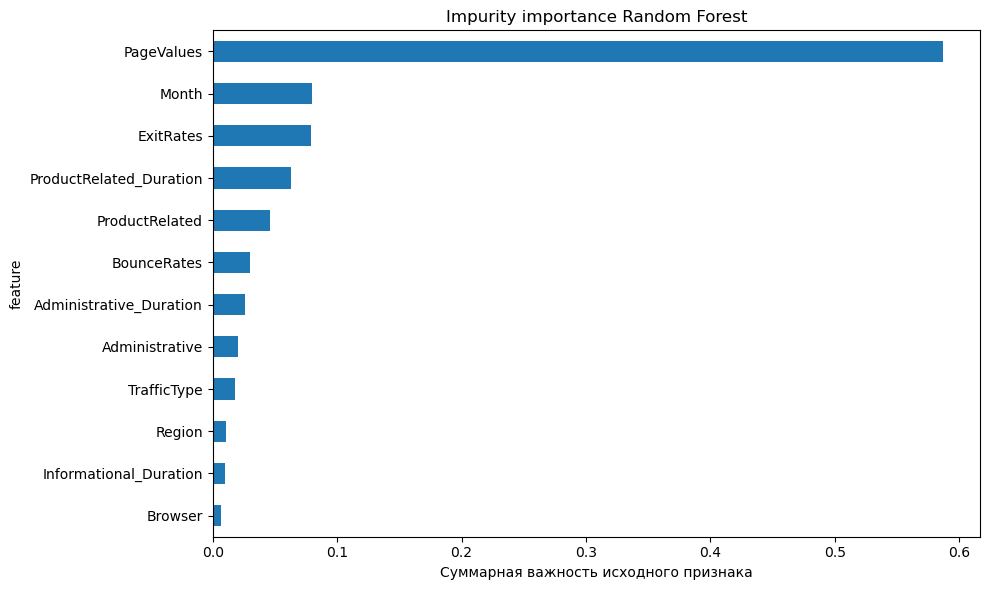

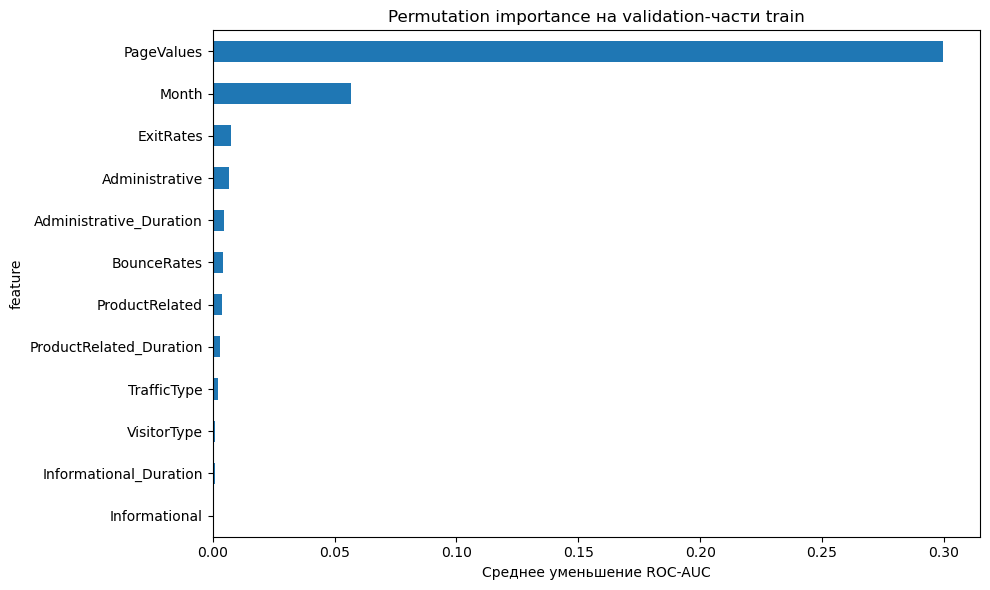

In [ ]:
(
    importance_df
    .sort_values("impurity_importance", ascending=True)
    .tail(12)
    .set_index("feature")["impurity_importance"]
    .plot.barh(figsize=(10, 6))
)
plt.title("Impurity importance Random Forest")
plt.xlabel("Суммарная важность исходного признака")
plt.tight_layout()
plt.show()

(
    importance_df
    .sort_values("permutation_importance", ascending=True)
    .tail(12)
    .set_index("feature")["permutation_importance"]
    .plot.barh(figsize=(10, 6))
)
plt.title("Permutation importance на validation-части train")
plt.xlabel("Среднее уменьшение ROC-AUC")
plt.tight_layout()
plt.show()

Два графика построены отдельно, потому что значения имеют разный смысл и разный масштаб.

**Вывод по H3. Гипотеза подтвердилась.**

В top-5 двух рейтингов совпали три признака: `PageValues`, `Month` и `ExitRates`. При этом impurity importance также выделил `ProductRelated_Duration` и `ProductRelated`, а permutation importance — `Administrative` и `Administrative_Duration`.

Оба метода находят общий основной сигнал, но по-разному оценивают часть признаков. Impurity importance основан на том, насколько часто и насколько эффективно признак используется в разбиениях деревьев. Permutation importance показывает, насколько ухудшается ROC-AUC после разрушения информации в конкретном исходном признаке.

### Эксперимент H4: удаление `ExitRates`

Чтобы проверить именно влияние удаления `ExitRates`, модели в каждой паре должны отличаться только этим столбцом.

Для Logistic Regression здесь намеренно не используем `SelectKBest`: иначе selector мог бы сам исключить `ExitRates`, и эксперимент уже не отвечал бы на поставленный вопрос. Параметры классификатора, CV-фолды и все остальные признаки остаются одинаковыми.

In [ ]:
reduced_numeric_cols = [
    col for col in numeric_cols
    if col != "ExitRates"
]

preprocessor_lr_all_h4 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", StandardScaler(), numeric_cols),
])
preprocessor_lr_reduced_h4 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", StandardScaler(), reduced_numeric_cols),
])

preprocessor_rf_all_h4 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", "passthrough", numeric_cols),
])
preprocessor_rf_reduced_h4 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("numeric", "passthrough", reduced_numeric_cols),
])

lr_all_h4 = Pipeline([
    ("preprocessor", preprocessor_lr_all_h4),
    ("classifier", LogisticRegression(
        max_iter=2000,
        **best_lr_classifier_params,
    )),
])
lr_without_exit_h4 = Pipeline([
    ("preprocessor", preprocessor_lr_reduced_h4),
    ("classifier", LogisticRegression(
        max_iter=2000,
        **best_lr_classifier_params,
    )),
])

rf_all_h4 = Pipeline([
    ("preprocessor", preprocessor_rf_all_h4),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        **best_rf_classifier_params,
    )),
])
rf_without_exit_h4 = Pipeline([
    ("preprocessor", preprocessor_rf_reduced_h4),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        **best_rf_classifier_params,
    )),
])

lr_all_h4_cv = evaluate_cv(
    lr_all_h4, X_train, y_train, cv, "LogReg: все признаки"
)
lr_without_exit_h4_cv = evaluate_cv(
    lr_without_exit_h4, X_train, y_train, cv, "LogReg: без ExitRates"
)
rf_all_h4_cv = evaluate_cv(
    rf_all_h4, X_train, y_train, cv, "RF: все признаки"
)
rf_without_exit_h4_cv = evaluate_cv(
    rf_without_exit_h4, X_train, y_train, cv, "RF: без ExitRates"
)

cv_table(
    lr_all_h4_cv,
    lr_without_exit_h4_cv,
    rf_all_h4_cv,
    rf_without_exit_h4_cv,
)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,LogReg: все признаки,0.903034,0.011900,0.651426,0.025238,0.530712,0.028213,0.756886,0.027600,0.623745,0.026619
1,LogReg: без ExitRates,0.904549,0.010318,0.650864,0.024036,0.550512,0.025491,0.749682,0.028052,0.634794,0.026345
2,RF: все признаки,0.933021,0.004428,0.752693,0.022639,0.596563,0.014253,0.784395,0.028600,0.677359,0.010836
3,RF: без ExitRates,0.932809,0.004901,0.745566,0.025901,0.593062,0.024175,0.787674,0.030580,0.676152,0.017364


In [ ]:
h4_lr_folds = paired_roc_auc_table(
    lr_all_h4_cv,
    lr_without_exit_h4_cv,
    "LogReg all",
    "LogReg without ExitRates",
)
h4_lr_folds

Средняя разница LogReg all - LogReg without ExitRates: -0.001514
Стандартное отклонение разницы: 0.003037
Фолдов, где LogReg all лучше: 2 из 5


,fold,LogReg all,LogReg without ExitRates,difference
0,1,0.905199,0.903453,0.001746
1,2,0.882156,0.887192,-0.005035
2,3,0.909575,0.908338,0.001237
3,4,0.907001,0.911022,-0.004021
4,5,0.911241,0.912740,-0.001499


In [ ]:
h4_rf_folds = paired_roc_auc_table(
    rf_all_h4_cv,
    rf_without_exit_h4_cv,
    "RF all",
    "RF without ExitRates",
)
h4_rf_folds

Средняя разница RF all - RF without ExitRates: 0.000211
Стандартное отклонение разницы: 0.001199
Фолдов, где RF all лучше: 3 из 5


,fold,RF all,RF without ExitRates,difference
0,1,0.930593,0.928575,0.002018
1,2,0.930272,0.929916,0.000356
2,3,0.930809,0.932063,-0.001253
3,4,0.940765,0.941117,-0.000352
4,5,0.932664,0.932376,0.000289


**Вывод по H4. Гипотеза подтвердилась частично.**

Удаление `ExitRates` сильнее изменило средний CV ROC-AUC Logistic Regression, чем Random Forest: примерно на 0.0015 против 0.0002.

Однако оба изменения малы и нестабильны по отдельным фолдам. Более того, после удаления `ExitRates` средний ROC-AUC Logistic Regression немного вырос - с 0.9030 до 0.9045. Это может означать, что признак частично дублирует информацию других переменных, прежде всего `BounceRates`, и не даёт линейной модели заметного дополнительного сигнала.

Поэтому формальное направление гипотезы подтвердилось, но практический эффект оказался слабым.

### Эксперимент H6: SelectKBest

В основном поиске было значение `k="all"`, поэтому победа такого варианта ничего не сказала бы об отборе признаков. Здесь проводим отдельный эксперимент:

- модель с `SelectKBest` проверяет только конечные значения `k`, то есть действительно сокращает набор;
- модель без `SelectKBest` использует все признаки;
- для обоих вариантов используется одинаковая сетка параметров Logistic Regression и одинаковые CV-фолды.

Параметры классификатора подбираются отдельно для каждого пайплайна. Это сделано намеренно: мы сравниваем лучшее качество, которое можно получить с отбором признаков и без него, а не две заранее зафиксированные конфигурации.

In [ ]:
grid_params_logreg_classifier = {
    "classifier__solver": ["liblinear"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
}

grid_params_logreg_selection = {
    **grid_params_logreg_classifier,
    "selector__k": [3, 5, 8, 10, 15],
}

model_logreg_with_selection = Pipeline([
    ("preprocessor", preprocessor_logreg),
    ("selector", SelectKBest(score_func=f_classif)),
    ("classifier", LogisticRegression(max_iter=2000)),
])

model_logreg_without_selection = Pipeline([
    ("preprocessor", preprocessor_logreg),
    ("classifier", LogisticRegression(max_iter=2000)),
])

result_logreg_with_selection = tune_model(
    model_logreg_with_selection,
    grid_params_logreg_selection,
    X_train,
    y_train,
    cv,
    "LogReg with SelectKBest",
)

result_logreg_without_selection = tune_model(
    model_logreg_without_selection,
    grid_params_logreg_classifier,
    X_train,
    y_train,
    cv,
    "LogReg without SelectKBest",
)

print("Лучшее k:", result_logreg_with_selection["best_params"]["selector__k"])
print("Параметры модели с отбором:")
display(result_logreg_with_selection["best_params"])
print("Параметры модели без отбора:")
display(result_logreg_without_selection["best_params"])

Лучшее k: 15
Параметры модели с отбором:


{'classifier__C': 0.01,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1',
 'classifier__solver': 'liblinear',
 'selector__k': 15}

Параметры модели без отбора:


{'classifier__C': 0.1,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1',
 'classifier__solver': 'liblinear'}

In [ ]:
selected_pipeline = result_logreg_with_selection["best_model"]

all_feature_names = (
    selected_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    selected_pipeline
    .named_steps["selector"]
    .get_support()
)

selected_features = all_feature_names[selected_mask]

print("Всего признаков после преобразования:", len(all_feature_names))
print("Выбрано признаков:", len(selected_features))

pd.DataFrame({
    "selected_feature": selected_features,
})

In [ ]:
h6_selected_cv = evaluate_cv(
    result_logreg_with_selection["best_model"],
    X_train,
    y_train,
    cv,
    "LogReg with SelectKBest",
)
h6_all_cv = evaluate_cv(
    result_logreg_without_selection["best_model"],
    X_train,
    y_train,
    cv,
    "LogReg without SelectKBest",
)

cv_table(h6_selected_cv, h6_all_cv)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_average_precision_mean,cv_average_precision_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
0,LogReg with SelectKBest,0.903340,0.009070,0.655533,0.021058,0.576216,0.021495,0.743776,0.021402,0.649235,0.019474
1,LogReg without SelectKBest,0.903035,0.011896,0.651424,0.025231,0.530459,0.028127,0.756886,0.027600,0.623574,0.026600


In [ ]:
h6_folds = paired_roc_auc_table(
    h6_selected_cv,
    h6_all_cv,
    "SelectKBest",
    "Без отбора",
)
h6_folds

Средняя разница SelectKBest - Без отбора: 0.000305
Стандартное отклонение разницы: 0.005239
Фолдов, где SelectKBest лучше: 3 из 5


,fold,SelectKBest,Без отбора,difference
0,1,0.905933,0.905187,0.000746
1,2,0.887932,0.882166,0.005766
2,3,0.909343,0.909577,-0.000235
3,4,0.910330,0.907001,0.003329
4,5,0.903160,0.911242,-0.008082


**Вывод по H6. Гипотеза подтвердилась частично.**

`SelectKBest` сократил преобразованный набор до 15 признаков. При этом средний CV ROC-AUC практически не изменился: 0.9033 с отбором против 0.9030 без отбора.

Модель с отбором показала более высокий результат на трёх фолдах из пяти, но разница между вариантами менялась от фолда к фолду. Значит, часть признаков можно убрать без заметной потери качества, однако устойчивого улучшения Logistic Regression от отбора признаков не получено.

## 10. Финальная оценка на test

До этого момента test не использовался. Теперь один раз обучаем выбранные Logistic Regression, Random Forest и Gradient Boosting на всём train и оцениваем на test.

Добавляем `DummyClassifier` как простую точку отсчёта. Он показывает качество модели, которая не использует закономерности в признаках. Для несбалансированной задачи кроме ROC-AUC выводим Average Precision, precision, recall и F1.

In [ ]:
dummy_model = Pipeline([
    ("preprocessor", preprocessor_rf_gb),
    ("classifier", DummyClassifier(strategy="prior")),
])

final_results = [
    evaluate_on_test(
        result_logreg["best_model"],
        X_train,
        y_train,
        X_test,
        y_test,
        "Logistic Regression",
    ),
    evaluate_on_test(
        result_rf["best_model"],
        X_train,
        y_train,
        X_test,
        y_test,
        "Random Forest",
    ),
    evaluate_on_test(
        result_gb["best_model"],
        X_train,
        y_train,
        X_test,
        y_test,
        "Gradient Boosting",
    ),
    evaluate_on_test(
        dummy_model,
        X_train,
        y_train,
        X_test,
        y_test,
        "DummyClassifier",
    ),
]

final_results_df = pd.DataFrame([
    {key: value for key, value in result.items() if key != "fitted_model"}
    for result in final_results
]).sort_values("roc_auc", ascending=False)

final_results_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
2,Gradient Boosting,0.900860,0.717391,0.604712,0.656250,0.936744,0.750363
1,Random Forest,0.881196,0.590196,0.787958,0.674888,0.933809,0.744735
0,Logistic Regression,0.852929,0.519393,0.806283,0.631795,0.913193,0.665802
3,DummyClassifier,0.843507,0.000000,0.000000,0.000000,0.500000,0.156493


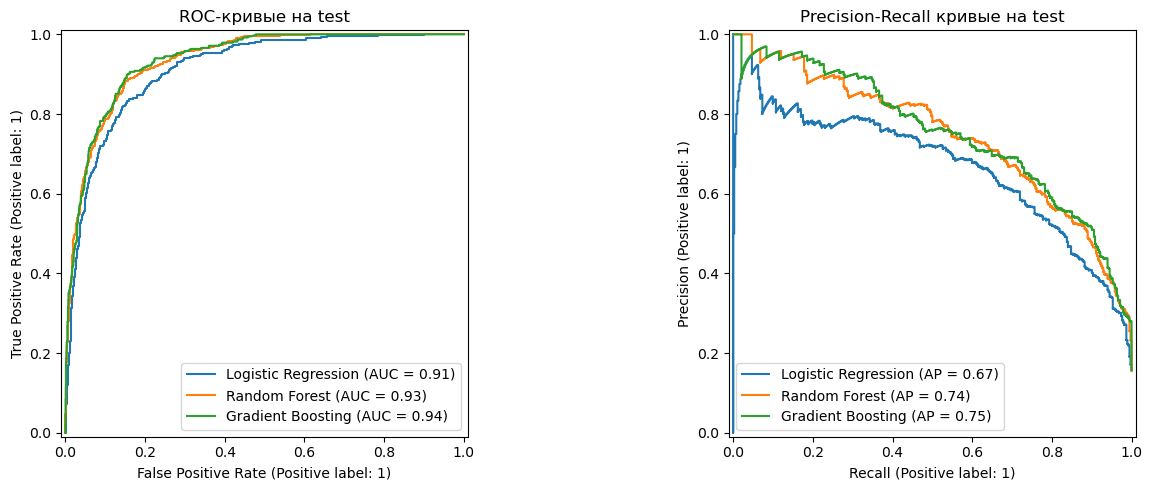

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for result in final_results[:-1]:
    RocCurveDisplay.from_estimator(
        result["fitted_model"],
        X_test,
        y_test,
        ax=axes[0],
        name=result["model"],
    )
    PrecisionRecallDisplay.from_estimator(
        result["fitted_model"],
        X_test,
        y_test,
        ax=axes[1],
        name=result["model"],
    )

axes[0].set_title("ROC-кривые на test")
axes[1].set_title("Precision-Recall кривые на test")
plt.tight_layout()
plt.show()

## 11. Итоговые выводы

Все три обученные модели значительно превосходят `DummyClassifier` по ROC-AUC и Average Precision. При этом `DummyClassifier` имеет accuracy 0.844, хотя вообще не находит покупки. Это показывает, почему при дисбалансе классов нельзя оценивать модель только по accuracy.

Gradient Boosting показал самый высокий test ROC-AUC - 0.937, Average Precision - 0.750 и precision - 0.717. Он реже ошибочно относит сессии без покупки к положительному классу, но его recall составляет 0.605, поэтому модель пропускает больше реальных покупателей.

Random Forest получил близкий ROC-AUC - 0.934. Его recall составил 0.788, а F1 - 0.675, что является лучшим значением F1 среди рассмотренных моделей. При стандартном пороге 0.5 эта модель даёт наиболее сбалансированное сочетание precision и recall.

Logistic Regression уступила ансамблевым моделям по ROC-AUC и precision, но показала самый высокий recall - 0.806. Она может быть полезна, если важнее обнаружить как можно больше потенциальных покупателей, даже ценой большего количества ложноположительных прогнозов.

Однозначно лучшей модели нет. Gradient Boosting даёт более точные положительные прогнозы, Random Forest обеспечивает лучший баланс precision и recall, а Logistic Regression - максимальный охват положительного класса. Для практического применения порог классификации следует выбирать с учётом стоимости пропущенного покупателя и лишнего воздействия на пользователя.